In [1]:
import torch
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")
import glob
from collections import OrderedDict
from ReportPretraining import ReportClassification
from src.layers.transformer.ATAT import LightCurveTransformer,TabularTransformer

from src.utils.data.AlerceDictionaries import ELASTICC_TAXONOMY, ZTF_TAXONOMY
import matplotlib.pyplot as plt
import numpy as np

In [2]:
DATASET  ='test'
DEVICE = 'cuda:0'
PATH_1 ='/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/results/PRETRAIN/LC/class_BASELINE_0/'
PATH_2 = '/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/results/PRETRAIN/LC/class_FINAL_v10_0/'

from src.utils.data.AlerceDictionaries import ELASTICC_TAXONOMY, ZTF_TAXONOMY

FP_DATASET = "/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/data/datasets/ZTF_ff/final/LC_MD_FEAT_240627_windows_200_12/dataset.h5"
#FP_DATASET = "/home/mdelafuente/ORIGINAL/elasticc_dataset_update.h5"
FP_DATASET ='/home/mdelafuente/ZTF_SSL_Dataset/data/H5_files/BY_PARTITION/200_FF.h5'

In [3]:
from src.exploringtools.InitBackbone import InitBackbone
from src.exploringtools.InitClassifier import InitClassifier, ztf_order_classes
from src.exploringtools.InitDataloader import InitDataLoader
from src.layers.classifiers.MultimodalClassifier import MultimodalClassifier
from src.layers.classifiers.HierClassifiery import Hier
from src.layers.transformer.ATAT import LightCurveTransformer


['/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/results/PRETRAIN/LC/class_BASELINE_0/classifier_ckpt_step=3648.ckpt']
Using checkpoint 3648.ckpt
['/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/results/PRETRAIN/LC/class_BASELINE_0/classifier_ckpt_step=3648.ckpt']
Using checkpoint 3648.ckpt
     - Loaded backbone weights
     - Loaded classifier weights
device set to cuda:0


100%|██████████| 477/477 [00:13<00:00, 34.97it/s]


                precision    recall  f1-score   support

           AGN     0.5603    0.3759    0.4499       556
           QSO     0.6239    0.7421    0.6779       570
            EA     0.8522    0.7789    0.8139       570
           YSO     0.6684    0.5298    0.5911       487
          SNIa     0.7468    0.6021    0.6667       485
       CV/Nova     0.6715    0.7281    0.6987       320
          RRLc     0.7368    0.7024    0.7192       578
         RSCVn     0.4931    0.4842    0.4886       444
        Blazar     0.5047    0.5926    0.5451       270
          SNII     0.7425    0.4526    0.5624       274
         EB/EW     0.6729    0.7439    0.7067       578
           LPV     0.8565    0.9155    0.8850       580
           CEP     0.7390    0.5654    0.6406       566
         RRLab     0.7424    0.8024    0.7713       582
Periodic-Other     0.3128    0.5083    0.3873       240
          DSCT     0.4822    0.5362    0.5078       304
         SNIbc     0.2993    0.4767    0.3677  

<Axes: title={'center': 'TimeFiLM + V&A + STATS + MD +FT | Dataset: test | macro f1: 0.5045'}, xlabel='Predicted label', ylabel='True label'>

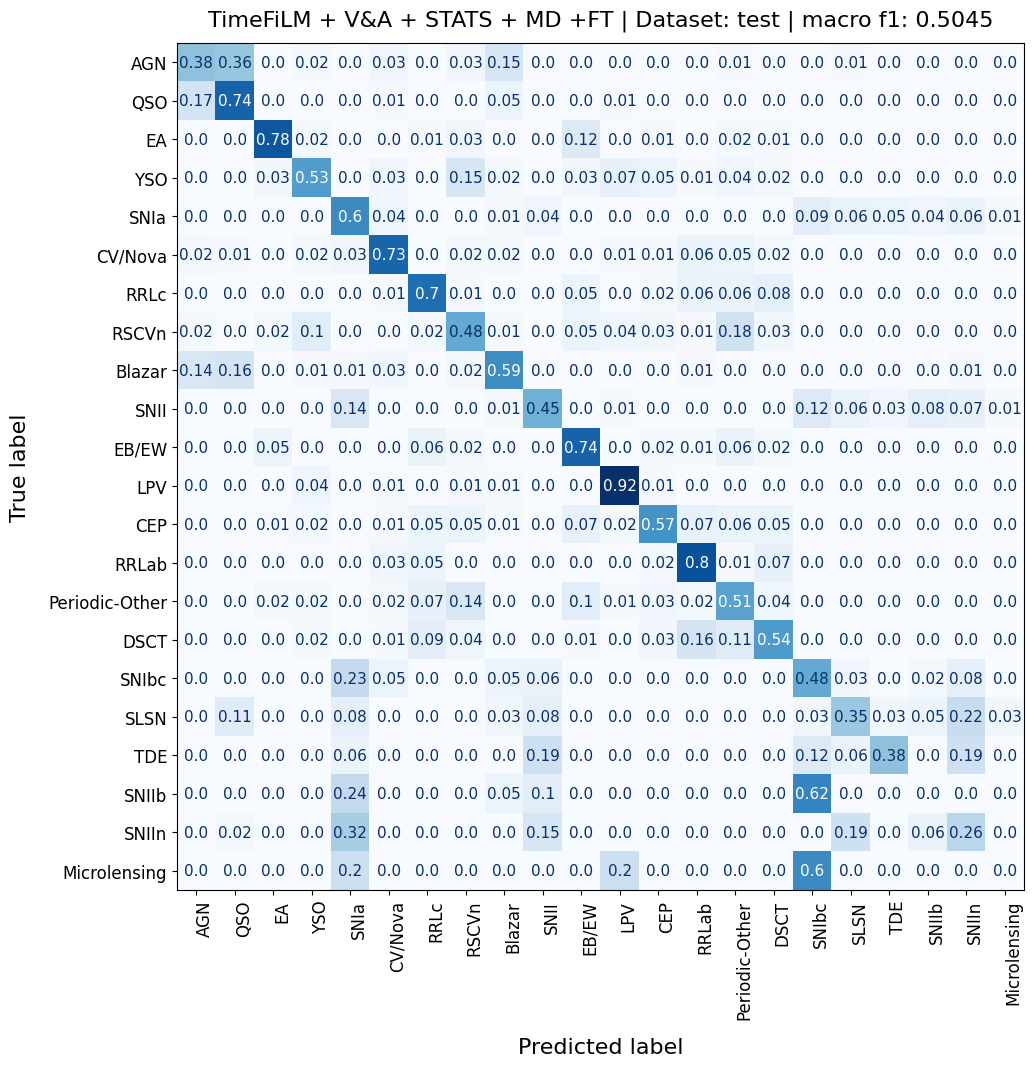

In [4]:
test = InitClassifier(path_to_config_yaml=PATH_1,
                    model= LightCurveTransformer,
                    classifier = MultimodalClassifier,
                    use_lc = True,
                    arg_key='lc')

backbone_od = test.create_ordered_dict(remove_if_in_key_list=['projection', 'classifier'],rename_keys = ('model.',''), checkpoint_name='classifier_ckpt')
classifier_od = test.create_ordered_dict(remove_if_in_key_list=['projection', 'model',],rename_keys = ('classifier.',''), checkpoint_name='classifier_ckpt')
test.load_backbone_weights(backbone_od)

test.load_classifier_weights(classifier_od)
test.args.datamodule.val_use_sampler = False

dl = InitDataLoader(update_dataset_path=FP_DATASET,update_batch_size=16,datamodule_args=test.args.datamodule)
dl.init_test_dataset()
import numpy as np
from sklearn.metrics import classification_report
val_preds, val_true =test.predict(dl.test_dataset, DEVICE) if DATASET == 'test' else test.predict(dl.validation_dataset, DEVICE)
report_1 = classification_report(val_true, np.argmax(val_preds, axis = -1), target_names=list(ZTF_TAXONOMY().keys()),digits = 4, output_dict=True)
print(classification_report(val_true, np.argmax(val_preds, axis = -1), target_names=list(ZTF_TAXONOMY().keys()),digits = 4, output_dict=False))
#test.get_confusion_matrix(np.argmax(val_preds, axis = -1), val_true, dataset_type=DATASET, taxonomy = ZTF_TAXONOMY, plot_title= 'ZTF ATAT LC ONLY', order_classes=ztf_order_classes)

test.get_confusion_matrix(np.argmax(val_preds, axis = -1), val_true, dataset_type=DATASET, taxonomy = ZTF_TAXONOMY, plot_title= 'TimeFiLM + V&A + STATS + MD +FT | Dataset', order_classes=list(ZTF_TAXONOMY().keys()))


In [5]:
import pandas as pd

df = pd.DataFrame({'true':val_true, 'pred':np.argmax(val_preds, axis = -1)})

transient_dict = ZTF_TAXONOMY.transient.group
transients = df.query('true in {}'.format(list(transient_dict.values())))
print(classification_report(transients['true'], transients['pred'],target_names= list(ZTF_TAXONOMY.transient.group.keys()),labels = list(ZTF_TAXONOMY.transient.group.values()),digits = 4, output_dict=False))

##
stochastic_dict = ZTF_TAXONOMY.stochastic.group
stochastics = df.query('true in {}'.format(list(stochastic_dict.values())))
print(classification_report(stochastics['true'], stochastics['pred'],target_names= list(ZTF_TAXONOMY.stochastic.group.keys()),labels = list(ZTF_TAXONOMY.stochastic.group.values()),digits = 4, output_dict=False))
####
periodic_dict = ZTF_TAXONOMY.periodic.group
periodics = df.query('true in {}'.format(list(periodic_dict.values())))
print(classification_report(periodics['true'], periodics['pred'],target_names= list(ZTF_TAXONOMY.periodic.group.keys()),labels = list(ZTF_TAXONOMY.periodic.group.values()),digits = 4, output_dict=False))


sum([classification_report(transients['true'], transients['pred'],target_names= list(ZTF_TAXONOMY.transient.group.keys()),labels = list(ZTF_TAXONOMY.transient.group.values()),digits = 4, output_dict=True)['macro avg']['f1-score'],
classification_report(stochastics['true'], stochastics['pred'],target_names= list(ZTF_TAXONOMY.stochastic.group.keys()),labels = list(ZTF_TAXONOMY.stochastic.group.values()),digits = 4, output_dict=True)['macro avg']['f1-score'],
classification_report(periodics['true'], periodics['pred'],target_names= list(ZTF_TAXONOMY.periodic.group.keys()),labels = list(ZTF_TAXONOMY.periodic.group.values()),digits = 4, output_dict=True)['macro avg']['f1-score']])/3

              precision    recall  f1-score   support

        SNIa     0.7725    0.6021    0.6767       485
        SNII     0.7561    0.4526    0.5662       274
       SNIbc     0.3060    0.4767    0.3727        86
        SLSN     0.1831    0.3514    0.2407        37
         TDE     0.1463    0.3750    0.2105        16
       SNIIb     0.0000    0.0000    0.0000        21
       SNIIn     0.1728    0.2642    0.2090        53
Microlensing     0.0000    0.0000    0.0000         5

   micro avg     0.5309    0.5015    0.5158       977
   macro avg     0.2921    0.3152    0.2845       977
weighted avg     0.6412    0.5015    0.5514       977

              precision    recall  f1-score   support

         AGN     0.5938    0.3759    0.4604       556
         QSO     0.6332    0.7421    0.6834       570
         YSO     0.9149    0.5298    0.6710       487
     CV/Nova     0.8381    0.7281    0.7793       320
      Blazar     0.5575    0.5926    0.5745       270

   micro avg     0.6872

0.5331374627180757

In [6]:
sum([classification_report(transients['true'], transients['pred'],target_names= list(ZTF_TAXONOMY.transient.group.keys()),labels = list(ZTF_TAXONOMY.transient.group.values()),digits = 4, output_dict=True)['macro avg']['f1-score'],
classification_report(stochastics['true'], stochastics['pred'],target_names= list(ZTF_TAXONOMY.stochastic.group.keys()),labels = list(ZTF_TAXONOMY.stochastic.group.values()),digits = 4, output_dict=True)['macro avg']['f1-score'],
classification_report(periodics['true'], periodics['pred'],target_names= list(ZTF_TAXONOMY.periodic.group.keys()),labels = list(ZTF_TAXONOMY.periodic.group.values()),digits = 4, output_dict=True)['macro avg']['f1-score']])/3

0.5331374627180757

['/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/results/PRETRAIN/LC/class_FINAL_v10_0/classifier_ckpt_step=3120.ckpt']
Using checkpoint 3120.ckpt
['/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/results/PRETRAIN/LC/class_FINAL_v10_0/classifier_ckpt_step=3120.ckpt']
Using checkpoint 3120.ckpt
     - Loaded backbone weights
     - Loaded classifier weights
device set to cuda:0


100%|██████████| 477/477 [00:07<00:00, 63.51it/s]


                precision    recall  f1-score   support

           AGN     0.5374    0.4263    0.4754       556
           QSO     0.6414    0.6965    0.6678       570
            EA     0.8589    0.7158    0.7809       570
           YSO     0.5605    0.6181    0.5879       487
          SNIa     0.8029    0.4619    0.5864       485
       CV/Nova     0.7626    0.6125    0.6794       320
          RRLc     0.6793    0.7439    0.7102       578
         RSCVn     0.5000    0.4527    0.4752       444
        Blazar     0.4535    0.5778    0.5081       270
          SNII     0.6784    0.4234    0.5213       274
         EB/EW     0.6624    0.7163    0.6883       578
           LPV     0.8695    0.8845    0.8769       580
           CEP     0.7182    0.5495    0.6226       566
         RRLab     0.7201    0.7955    0.7559       582
Periodic-Other     0.3710    0.3833    0.3770       240
          DSCT     0.4452    0.6151    0.5166       304
         SNIbc     0.2527    0.5349    0.3433  

<Axes: title={'center': 'TimeFiLM + V&A + STATS + MD +FT | Dataset: test | macro f1: 0.4865'}, xlabel='Predicted label', ylabel='True label'>

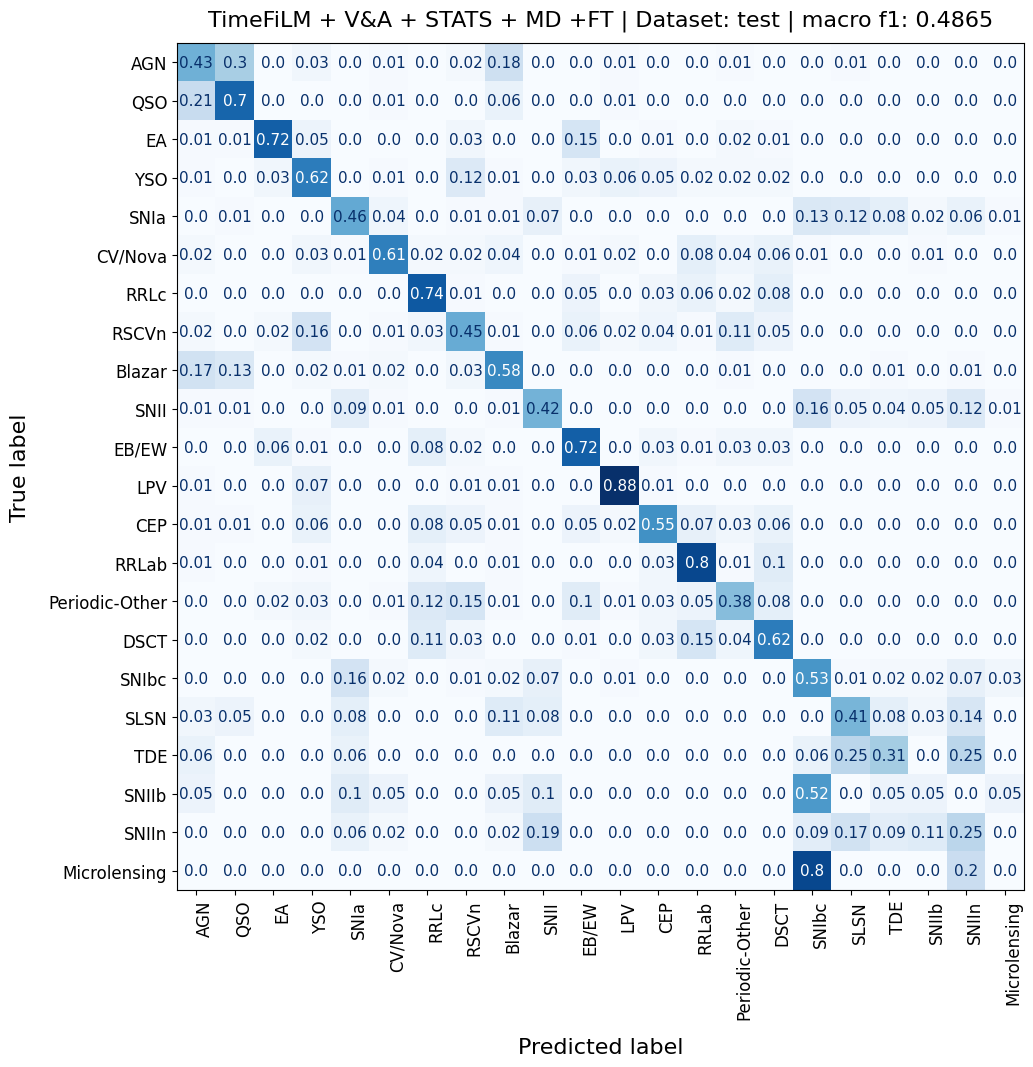

In [11]:
test = InitClassifier(path_to_config_yaml=PATH_2,
                    model= LightCurveTransformer,
                    classifier = MultimodalClassifier,
                    use_lc = True,
                    arg_key='lc')

backbone_od = test.create_ordered_dict(remove_if_in_key_list=['projection', 'classifier'],rename_keys = ('model.',''), checkpoint_name='classifier_ckpt')
classifier_od = test.create_ordered_dict(remove_if_in_key_list=['projection', 'model',],rename_keys = ('classifier.',''), checkpoint_name='classifier_ckpt')
test.load_backbone_weights(backbone_od)

test.load_classifier_weights(classifier_od)
test.args.datamodule.val_use_sampler = False

dl = InitDataLoader(update_dataset_path=FP_DATASET,update_batch_size=16,datamodule_args=test.args.datamodule)
dl.init_test_dataset()
import numpy as np
from sklearn.metrics import classification_report
val_preds, val_true =test.predict(dl.test_dataset, DEVICE) if DATASET == 'test' else test.predict(dl.validation_dataset, DEVICE)
report_2 = classification_report(val_true, np.argmax(val_preds, axis = -1), target_names=list(ZTF_TAXONOMY().keys()),digits = 4, output_dict=True)
print(classification_report(val_true, np.argmax(val_preds, axis = -1), target_names=list(ZTF_TAXONOMY().keys()),digits = 4, output_dict=False))
#test.get_confusion_matrix(np.argmax(val_preds, axis = -1), val_true, dataset_type=DATASET, taxonomy = ZTF_TAXONOMY, plot_title= 'ZTF ATAT LC ONLY', order_classes=ztf_order_classes)

test.get_confusion_matrix(np.argmax(val_preds, axis = -1), val_true, dataset_type=DATASET, taxonomy = ZTF_TAXONOMY, plot_title= 'TimeFiLM + V&A + STATS + MD +FT | Dataset', order_classes=list(ZTF_TAXONOMY().keys()))


In [8]:
import pandas as pd

df = pd.DataFrame({'true':val_true, 'pred':np.argmax(val_preds, axis = -1)})

transient_dict = ZTF_TAXONOMY.transient.group
transients = df.query('true in {}'.format(list(transient_dict.values())))
print(classification_report(transients['true'], transients['pred'],target_names= list(ZTF_TAXONOMY.transient.group.keys()),labels = list(ZTF_TAXONOMY.transient.group.values()),digits = 4, output_dict=False))

##
stochastic_dict = ZTF_TAXONOMY.stochastic.group
stochastics = df.query('true in {}'.format(list(stochastic_dict.values())))
print(classification_report(stochastics['true'], stochastics['pred'],target_names= list(ZTF_TAXONOMY.stochastic.group.keys()),labels = list(ZTF_TAXONOMY.stochastic.group.values()),digits = 4, output_dict=False))
####
periodic_dict = ZTF_TAXONOMY.periodic.group
periodics = df.query('true in {}'.format(list(periodic_dict.values())))
print(classification_report(periodics['true'], periodics['pred'],target_names= list(ZTF_TAXONOMY.periodic.group.keys()),labels = list(ZTF_TAXONOMY.periodic.group.values()),digits = 4, output_dict=False))


sum([classification_report(transients['true'], transients['pred'],target_names= list(ZTF_TAXONOMY.transient.group.keys()),labels = list(ZTF_TAXONOMY.transient.group.values()),digits = 4, output_dict=True)['macro avg']['f1-score'],
classification_report(stochastics['true'], stochastics['pred'],target_names= list(ZTF_TAXONOMY.stochastic.group.keys()),labels = list(ZTF_TAXONOMY.stochastic.group.values()),digits = 4, output_dict=True)['macro avg']['f1-score'],
classification_report(periodics['true'], periodics['pred'],target_names= list(ZTF_TAXONOMY.periodic.group.keys()),labels = list(ZTF_TAXONOMY.periodic.group.values()),digits = 4, output_dict=True)['macro avg']['f1-score']])/3

              precision    recall  f1-score   support

        SNIa     0.7809    0.5216    0.6255       485
        SNII     0.7333    0.4818    0.5815       274
       SNIbc     0.2643    0.4302    0.3274        86
        SLSN     0.1605    0.3514    0.2203        37
         TDE     0.0390    0.1875    0.0645        16
       SNIIb     0.0833    0.0952    0.0889        21
       SNIIn     0.1184    0.1698    0.1395        53
Microlensing     0.0000    0.0000    0.0000         5

   micro avg     0.4956    0.4596    0.4769       977
   macro avg     0.2725    0.2797    0.2560       977
weighted avg     0.6315    0.4596    0.5213       977

              precision    recall  f1-score   support

         AGN     0.5340    0.4946    0.5135       556
         QSO     0.6575    0.6263    0.6415       570
         YSO     0.8831    0.6982    0.7798       487
     CV/Nova     0.8961    0.6469    0.7514       320
      Blazar     0.5106    0.5333    0.5217       270

   micro avg     0.6764

0.5140821361430573

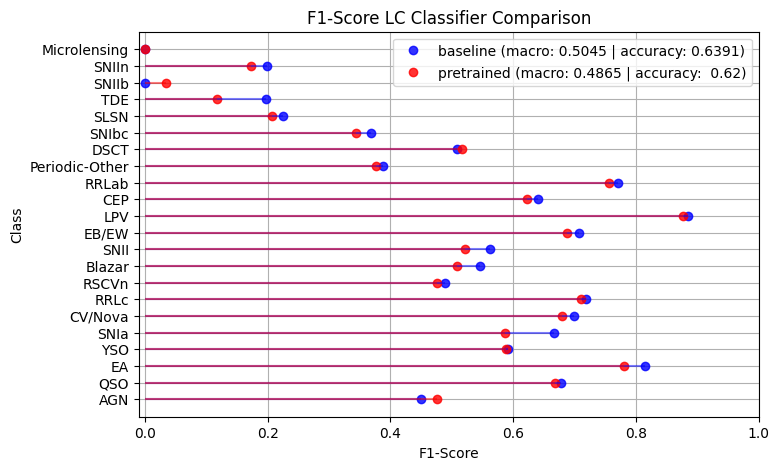

baseline f1 mean:
trans 0.2770223438235679
stoch 0.59253831298377
per 0.6578265116084798
pretrained f1 mean:
trans 0.26236408924598753
stoch 0.5881315931610755
per 0.6513333990660829


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
def compare_models(d1,d2, eval_time= 2048):

    f1_baseline = []
    f1_finetune = []

    fig,ax = plt.subplots(1,1,figsize = (8,5))
    for key,value in d1.items():
       # print(key,value)
        if key in ZTF_TAXONOMY().keys():

            f1_baseline.append(value['f1-score'])

    df_1 = pd.DataFrame({'group':ZTF_TAXONOMY().keys(), 'values':f1_baseline })
    ordered_df_1 = df_1 #.sort_values(by='values')
    my_range_1=range(1,len(df_1.index)+1)

    for key,value in d2.items():
        if key in (ZTF_TAXONOMY().keys()):
            #print(key,value)
            f1_finetune.append(value['f1-score'])
    df_2 = pd.DataFrame({'group':ZTF_TAXONOMY().keys(), 'values':f1_finetune})
    ordered_df_2 = df_2 #.sort_values(by='values')
    my_range_2=range(1,len(df_2.index)+1)
    plt.plot(ordered_df_1['values'].values, my_range_1, "o", alpha = 0.8,color='blue')
    plt.plot(ordered_df_2['values'].values, my_range_2, "o", alpha = 0.8,color='red')

    plt.legend(['1','2'])

    # The horizontal plot is made using the hline function
    plt.hlines(y=my_range_1, xmin=0, xmax=ordered_df_1['values'], color='blue', alpha = 0.5)

    # The horizontal plot is made using the hline function
    plt.hlines(y=my_range_2, xmin=0, xmax=ordered_df_2['values'], color='red', alpha = 0.5)

    # Add titles and axis names
    plt.yticks(my_range_1, ordered_df_1['group'])
    plt.title(f"F1-Score LC Classifier Comparison", loc='center')

    plt.xlabel('F1-Score')
    plt.ylabel('Class')
    plt.xlim(-0.01,1)
    #plt.xticks(np.arange(0,1,50), ordered_df_1['group'])
    plt.grid('on', )

    plt.legend([f'baseline (macro: {np.round(d1['macro avg']['f1-score'],4)} | accuracy: {np.round(d1['accuracy'],4)})',
                f'pretrained (macro: {np.round(d2['macro avg']['f1-score'],4)} | accuracy:  {np.round(d2['accuracy'],4)})'])
    # Show the plot
    plt.show()
compare_models(report_1,report_2)

transient =  {
    "SNIa": 4,
    "SNII": 9,
    "SNIbc": 16,
    "SLSN": 17,
    "TDE": 18,
    "SNIIb": 19,
    "SNIIn": 20,
    "Microlensing": 21
}

stochastic =  {
    "AGN": 0,
    "QSO": 1,
    "YSO": 3,
    "CV/Nova": 5,
    "Blazar": 8,
}

periodic =  {
    "EA": 2,
    "RRLc": 6,
    "RSCVn": 7,
    "EB/EW": 10,
    "LPV": 11,
    "CEP": 12,
    "RRLab": 13,
    "Periodic-Other": 14,
    "DSCT": 15,
}
import numpy as np
trans_f1 = []
stoch_f1 = []
per_f1 = []
for class_key, value in report_1.items():
    #print(class_key)
    if class_key in ZTF_TAXONOMY().keys():

        if class_key in transient.keys():
            trans_f1.append(value['f1-score'])
        if class_key in stochastic.keys():
            stoch_f1.append(value['f1-score'])
        if class_key in periodic.keys():
            per_f1.append(value['f1-score'])
print('baseline f1 mean:')
print('trans',np.mean(trans_f1))
print('stoch',np.mean(stoch_f1))
print('per',np.mean(per_f1))
for class_key, value in report_2.items():
    #print(class_key)
    if class_key in ZTF_TAXONOMY().keys():

        if class_key in transient.keys():
            trans_f1.append(value['f1-score'])
        if class_key in stochastic.keys():
            stoch_f1.append(value['f1-score'])
        if class_key in periodic.keys():
            per_f1.append(value['f1-score'])
print('pretrained f1 mean:')
print('trans',np.mean(trans_f1))
print('stoch',np.mean(stoch_f1))
print('per',np.mean(per_f1))